[find the best features for machine learning](https://www.youtube.com/watch?v=hCwTDTdYirg)

[youtube](https://www.youtube.com/watch?v=YaKMeAlHgqQ)

[scikit learn documentation](https://scikit-learn.org/stable/modules/feature_selection.html)

In [5]:
import pandas as pd
import numpy as np

# Simulate a dataset with 500 samples
np.random.seed(42)

df = pd.DataFrame({
    # Process parameters
    "Tube_Diameter": np.random.uniform(20, 60, 500),
    "Wall_Thickness": np.random.uniform(1, 5, 500),
    "Collet_Boost": np.random.uniform(0, 10, 500),
    "Mandrel_Timing": np.random.uniform(0, 1, 500),
    "Pressure_Die_Clearance": np.random.uniform(0, 2, 500),
    
    # Tool force/movement signals (simplified as average values)
    "BendDie_Force": np.random.uniform(100, 300, 500),
    "Mandrel_Force": np.random.uniform(50, 150, 500),
    "WiperDie_Force": np.random.uniform(20, 100, 500),
    
    # Labels (geometry results, like in the paper)
    "Secondary_Axis": np.random.uniform(0, 1, 500),
    "Main_Axis": np.random.uniform(0, 1, 500),
    "Out_of_Roundness": np.random.uniform(0, 0.01, 500),
    "Collapse": np.random.uniform(0, 0.2, 500)
})

df.head()


,Tube_Diameter,Wall_Thickness,Collet_Boost,Mandrel_Timing,Pressure_Die_Clearance,BendDie_Force,Mandrel_Force,WiperDie_Force,Secondary_Axis,Main_Axis,Out_of_Roundness,Collapse
0,34.981605,3.792647,1.851329,0.519082,0.523411,265.503784,117.270299,42.921564,0.571996,0.599299,0.003936,0.103750
1,58.028572,3.144385,5.419009,0.479182,0.493958,252.905559,129.668140,84.211225,0.805432,0.513708,0.004734,0.010233
2,49.279758,2.238110,8.729458,0.025642,1.812509,214.705790,75.046790,99.779032,0.760161,0.288185,0.008545,0.046572
3,43.946339,4.255180,7.322249,0.341248,0.499092,291.209429,112.487410,22.402080,0.153900,0.006464,0.003400,0.098400
4,26.240746,3.738925,8.065611,0.380196,0.543899,140.094903,107.174598,91.789269,0.149249,0.496239,0.008696,0.062047


# 1. Filter Methods (Correlation, Mutual Information, ANOVA)

Correlation Heatmap → shows how features are linearly related to labels.

Mutual Information (MI) → captures nonlinear dependencies between features and the chosen label (Collapse here).

ANOVA F-test → measures how well each feature explains the variance in the label.

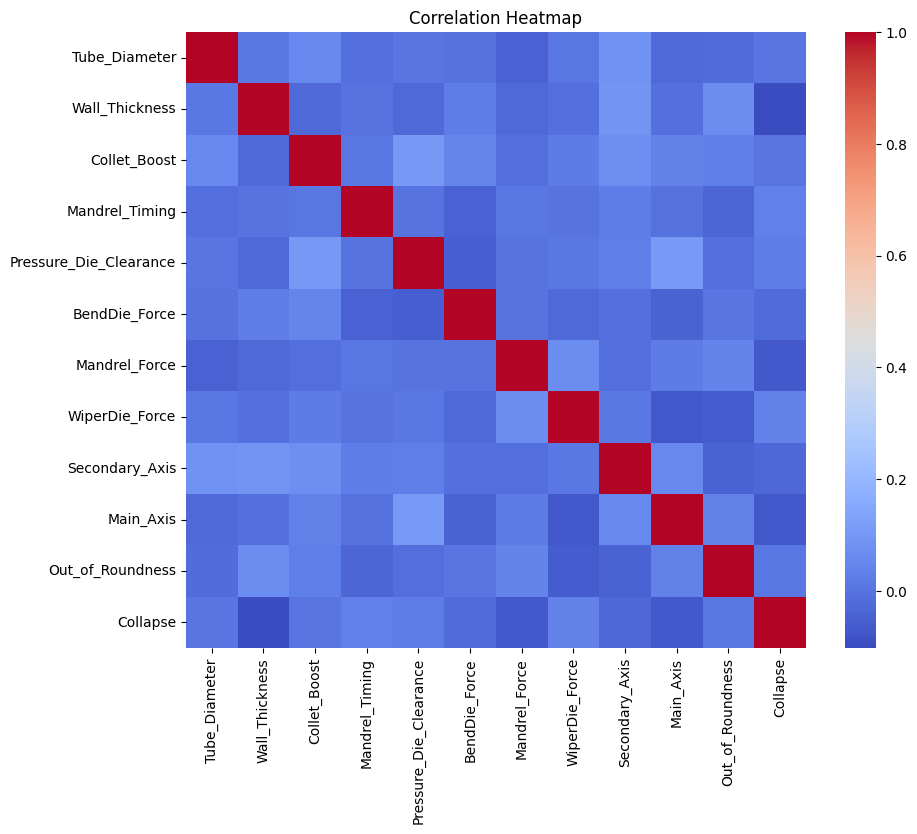

Top features by Mutual Information:
 Mandrel_Timing            0.066220
Collet_Boost              0.039320
WiperDie_Force            0.038706
Wall_Thickness            0.024248
Tube_Diameter             0.024084
Pressure_Die_Clearance    0.008386
BendDie_Force             0.000000
Mandrel_Force             0.000000
dtype: float64 

Top features by ANOVA F-test:
 Wall_Thickness            5.297491
Mandrel_Force             2.458896
WiperDie_Force            0.729063
Mandrel_Timing            0.522324
BendDie_Force             0.295430
Pressure_Die_Clearance    0.261793
Tube_Diameter             0.010287
Collet_Boost              0.008968
dtype: float64


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression, f_regression

# --- Split features and labels ---
X = df.drop(columns=["Secondary_Axis", "Main_Axis", "Out_of_Roundness", "Collapse"])
y = df["Collapse"]  # example for one label

# --- Pearson Correlation ---
corr = df.corr(numeric_only=True)  # numeric_only=True avoids warnings if df has non-numeric cols
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# --- Mutual Information ---
mi = mutual_info_regression(X, y)
mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)
print("Top features by Mutual Information:\n", mi_series, "\n")

# --- ANOVA F-test ---
f_values, _ = f_regression(X, y)
f_series = pd.Series(f_values, index=X.columns).sort_values(ascending=False)
print("Top features by ANOVA F-test:\n", f_series)


# 2. Wrapper Methods (RFE, Forward Selection)

In [9]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor

# Example with Random Forest + RFE
model = RandomForestRegressor(n_estimators=100, random_state=42)
rfe = RFE(model, n_features_to_select=5)  # choose top 5
rfe.fit(X, y)

selected_features = X.columns[rfe.support_]
print("Selected features by RFE:", list(selected_features))


Selected features by RFE: ['Tube_Diameter', 'Wall_Thickness', 'Mandrel_Timing', 'Pressure_Die_Clearance', 'BendDie_Force']


# 2. Wrapper Methods (RFE, Forward Selection)

In [14]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

sfs = SFS(model, 
          k_features=5, 
          forward=True, 
          scoring='neg_mean_squared_error', 
          cv=5)
sfs.fit(X, y)

print("Forward Selected Features:", list(sfs.k_feature_names_))


Forward Selected Features: ['Wall_Thickness', 'Collet_Boost', 'Mandrel_Timing', 'Mandrel_Force', 'WiperDie_Force']


# 3. Embedded Methods (RF, Lasso, ElasticNet)

Embedded Methods

How they work: Feature selection occurs during model training. The model inherently decides which features are important.

Pros: More efficient than wrapper methods; takes into account feature interactions.

Cons: Depends on the specific model; less flexible than wrappers in some cases.

Examples:

Random Forest Feature Importance

Measures how much each feature reduces impurity (Gini or MSE) across all trees.

Feature importance is directly output by the model.

Lasso Regression (L1 Regularization)

Shrinks some coefficients to zero, effectively removing unimportant features.

ElasticNet (L1 + L2 Regularization)

Combines Lasso (L1) and Ridge (L2) penalties.

Good for correlated features.

In [10]:
from sklearn.linear_model import LassoCV, ElasticNetCV
import numpy as np

# --- Random Forest Feature Importance ---
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("RF Feature Importances:\n", importances)

# --- Lasso Regression ---
lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X, y)
lasso_importance = pd.Series(np.abs(lasso.coef_), index=X.columns).sort_values(ascending=False)
print("Lasso Feature Importances:\n", lasso_importance)

# --- ElasticNet ---
enet = ElasticNetCV(cv=5, random_state=42)
enet.fit(X, y)
enet_importance = pd.Series(np.abs(enet.coef_), index=X.columns).sort_values(ascending=False)
print("ElasticNet Feature Importances:\n", enet_importance)


RF Feature Importances:
 Wall_Thickness            0.145925
Mandrel_Timing            0.139522
Pressure_Die_Clearance    0.136490
Tube_Diameter             0.126245
Mandrel_Force             0.118253
BendDie_Force             0.111462
WiperDie_Force            0.111086
Collet_Boost              0.111017
dtype: float64
Lasso Feature Importances:
 Mandrel_Force             0.00001
Tube_Diameter             0.00000
Collet_Boost              0.00000
Wall_Thickness            0.00000
Mandrel_Timing            0.00000
Pressure_Die_Clearance    0.00000
BendDie_Force             0.00000
WiperDie_Force            0.00000
dtype: float64
ElasticNet Feature Importances:
 Mandrel_Force             0.00001
Tube_Diameter             0.00000
Collet_Boost              0.00000
Wall_Thickness            0.00000
Mandrel_Timing            0.00000
Pressure_Die_Clearance    0.00000
BendDie_Force             0.00000
WiperDie_Force            0.00000
dtype: float64


# 4. Dimensionality Reduction (PCA, Autoencoder)

In [11]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize first
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- PCA ---
pca = PCA(n_components=5)  # keep top 5 components
X_pca = pca.fit_transform(X_scaled)

print("Explained variance by each component:", pca.explained_variance_ratio_)


Explained variance by each component: [0.14187042 0.13865106 0.13114801 0.12553736 0.12313205]


# 5. Advanced Interpretability (Permutation, SHAP, LIME)

Permutation Feature Importance

How it works:

Train your model normally.

Shuffle one feature’s values across all samples (breaks its relationship with target).

Measure the drop in model performance (e.g., R², MAE, MSE).

Big drop → feature is important.

Pros: Model-agnostic, works with any model.

Cons: Can be slow for large datasets; correlated features may get underestimated.

SHAP (SHapley Additive exPlanations)

How it works:

Uses game theory to assign an importance value (“SHAP value”) to each feature for each prediction.

Measures how much each feature contributes positively or negatively to a specific prediction.

Pros:

Consistent, theoretically sound, works for complex models (trees, neural networks, etc.).

Gives local explanations (per sample) and global explanations (overall importance).

Cons: Can be computationally expensive for large datasets.